# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

RAW_PATH = "/content/drive/MyDrive/SMSML_Ardi-Febriansyah/Eksperimen_SML_Ardi-Febriansyah/heart_raw/heart.csv"

df = pd.read_csv(RAW_PATH)

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [6]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["num"].value_counts()

,count
num,
0,411
1,265
2,109
3,107
4,28


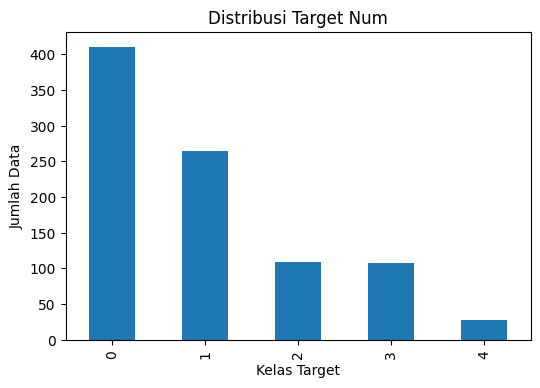

In [9]:
plt.figure(figsize=(6, 4))
df["num"].value_counts().plot(kind="bar")
plt.title("Distribusi Target Num")
plt.xlabel("Kelas Target")
plt.ylabel("Jumlah Data")
plt.show()

In [10]:
df.dtypes

,0
id,int64
age,int64
sex,object
dataset,object
cp,object
trestbps,float64
chol,float64
fbs,object
restecg,object
thalch,float64


In [11]:
cat_cols = df.select_dtypes(include=["object", "bool"]).columns

for col in cat_cols:
    print(f"Kolom: {col}")
    print(df[col].value_counts())
    print("-" * 40)

Kolom: sex
sex
Male      726
Female    194
Name: count, dtype: int64
----------------------------------------
Kolom: dataset
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64
----------------------------------------
Kolom: cp
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64
----------------------------------------
Kolom: fbs
fbs
False    692
True     138
Name: count, dtype: int64
----------------------------------------
Kolom: restecg
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64
----------------------------------------
Kolom: exang
exang
False    528
True     337
Name: count, dtype: int64
----------------------------------------
Kolom: slope
slope
flat           345
upsloping      203
downsloping     63
Name: count, dtype: int64
----------------------------------------
Kolom: thal
thal
no

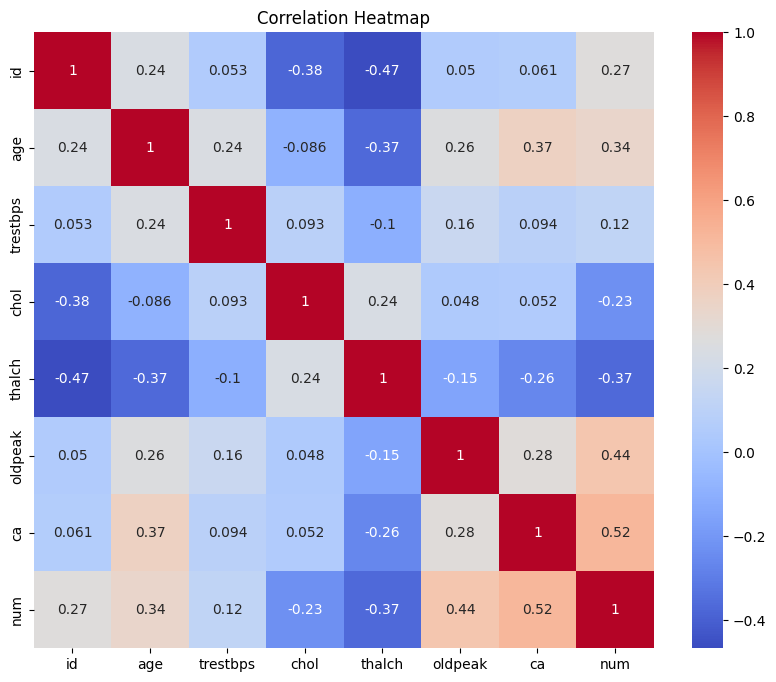

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

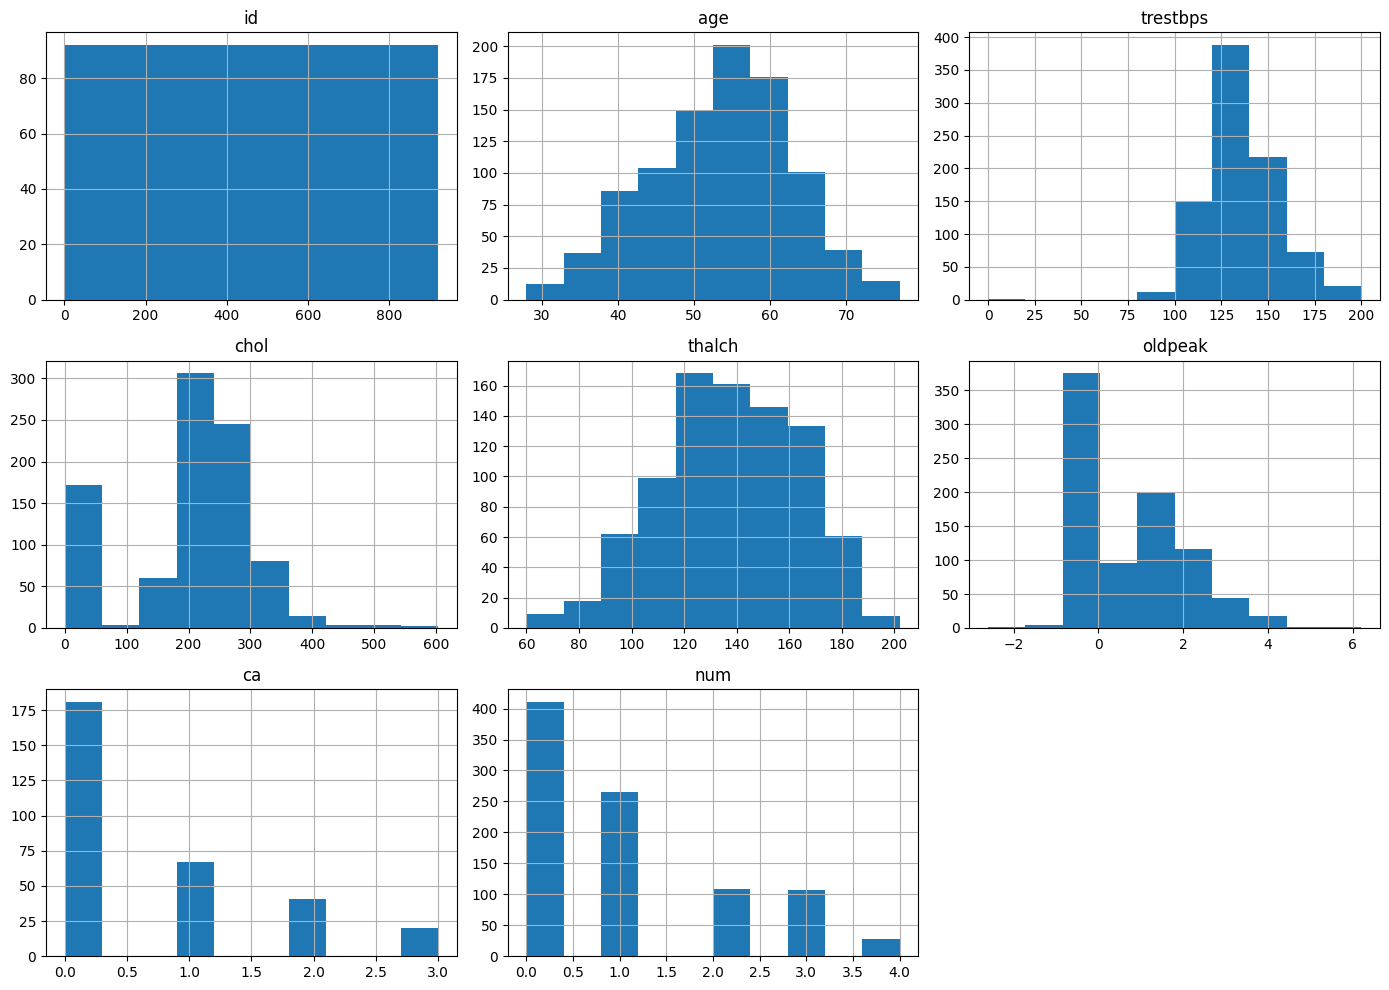

In [13]:
df.hist(figsize=(14, 10))
plt.tight_layout()
plt.show()

 # **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [14]:
df_clean = df.copy()

df_clean = df_clean.drop(columns=["id"])

df_clean.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [15]:
df_clean = df_clean.drop_duplicates()

df_clean.shape

(918, 15)

In [16]:
df_clean["num"] = df_clean["num"].apply(lambda x: 0 if x == 0 else 1)

df_clean["num"].value_counts()

,count
num,
1,508
0,410


In [17]:
num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df_clean.select_dtypes(include=["object", "bool"]).columns

df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_clean.isnull().sum()

/tmp/ipykernel_644/605609963.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])


,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0


In [18]:
df_encoded = pd.get_dummies(df_clean, drop_first=True)

df_encoded.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,sex_Male,...,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,True,150.0,False,2.3,0.0,0,True,...,False,False,False,True,False,False,False,False,False,False
1,67,160.0,286.0,False,108.0,True,1.5,3.0,1,True,...,False,False,False,False,False,False,True,False,True,False
2,67,120.0,229.0,False,129.0,True,2.6,2.0,1,True,...,False,False,False,False,False,False,True,False,False,True
3,37,130.0,250.0,False,187.0,False,3.5,0.0,0,True,...,False,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,0.0,0,False,...,False,True,False,False,False,False,False,True,True,False


In [19]:
X = df_encoded.drop(columns=["num"])
y = df_encoded["num"]

print("Jumlah fitur:", X.shape)
print("Jumlah target:", y.shape)

Jumlah fitur: (918, 21)
Jumlah target: (918,)


In [22]:
X = df_encoded.drop(columns=["num"])
y = df_encoded["num"]

print("Jumlah fitur:", X.shape)
print("Jumlah target:", y.shape)

Jumlah fitur: (918, 21)
Jumlah target: (918,)


In [24]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,sex_Male,dataset_Hungary,...,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,1.006537,0.705085,0.303747,2.377430,0.489681,-0.759815,1.365834,-0.361845,0.515952,-0.682974,...,-0.526092,-0.481887,-0.532838,4.353909,-1.228087,-0.490449,-1.565608,-0.532838,-1.690309,-0.514259
1,1.430829,1.518645,0.789562,-0.420622,-1.180980,1.316109,0.609600,4.406195,0.515952,-0.682974,...,-0.526092,-0.481887,-0.532838,-0.229679,-1.228087,-0.490449,0.638730,-0.532838,0.591608,-0.514259
2,1.430829,-0.650848,0.267081,-0.420622,-0.345649,1.316109,1.649422,2.816848,0.515952,-0.682974,...,-0.526092,-0.481887,-0.532838,-0.229679,-1.228087,-0.490449,0.638730,-0.532838,-1.690309,1.944544
3,-1.751359,-0.108475,0.459574,-0.420622,1.961454,-0.759815,2.500185,-0.361845,0.515952,-0.682974,...,-0.526092,-0.481887,1.876744,-0.229679,0.814275,-0.490449,-1.565608,-0.532838,0.591608,-0.514259
4,-1.327067,-0.108475,0.037923,-0.420622,1.364789,-0.759815,0.515071,-0.361845,-1.938163,-0.682974,...,-0.526092,2.075177,-0.532838,-0.229679,-1.228087,-0.490449,-1.565608,1.876744,0.591608,-0.514259


In [26]:
df_preprocessed = pd.concat(
    [X_scaled_df, y.reset_index(drop=True)],
    axis=1
)

df_preprocessed.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,sex_Male,dataset_Hungary,...,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect,num
0,1.006537,0.705085,0.303747,2.377430,0.489681,-0.759815,1.365834,-0.361845,0.515952,-0.682974,...,-0.481887,-0.532838,4.353909,-1.228087,-0.490449,-1.565608,-0.532838,-1.690309,-0.514259,0
1,1.430829,1.518645,0.789562,-0.420622,-1.180980,1.316109,0.609600,4.406195,0.515952,-0.682974,...,-0.481887,-0.532838,-0.229679,-1.228087,-0.490449,0.638730,-0.532838,0.591608,-0.514259,1
2,1.430829,-0.650848,0.267081,-0.420622,-0.345649,1.316109,1.649422,2.816848,0.515952,-0.682974,...,-0.481887,-0.532838,-0.229679,-1.228087,-0.490449,0.638730,-0.532838,-1.690309,1.944544,1
3,-1.751359,-0.108475,0.459574,-0.420622,1.961454,-0.759815,2.500185,-0.361845,0.515952,-0.682974,...,-0.481887,1.876744,-0.229679,0.814275,-0.490449,-1.565608,-0.532838,0.591608,-0.514259,0
4,-1.327067,-0.108475,0.037923,-0.420622,1.364789,-0.759815,0.515071,-0.361845,-1.938163,-0.682974,...,2.075177,-0.532838,-0.229679,-1.228087,-0.490449,-1.565608,1.876744,0.591608,-0.514259,0


In [27]:
df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       918 non-null    float64
 1   trestbps                  918 non-null    float64
 2   chol                      918 non-null    float64
 3   fbs                       918 non-null    float64
 4   thalch                    918 non-null    float64
 5   exang                     918 non-null    float64
 6   oldpeak                   918 non-null    float64
 7   ca                        918 non-null    float64
 8   sex_Male                  918 non-null    float64
 9   dataset_Hungary           918 non-null    float64
 10  dataset_Switzerland       918 non-null    float64
 11  dataset_VA Long Beach     918 non-null    float64
 12  cp_atypical angina        918 non-null    float64
 13  cp_non-anginal            918 non-null    float64
 14  cp_typical

In [28]:
df_preprocessed.isnull().sum()

,0
age,0
trestbps,0
chol,0
fbs,0
thalch,0
exang,0
oldpeak,0
ca,0
sex_Male,0
dataset_Hungary,0


In [29]:
df_preprocessed["num"].value_counts()

,count
num,
1,508
0,410
